In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: False


In [33]:
ds = pickle.load(open('sgp_set_cnn','rb'))

In [34]:
ds['kappa'].loc[ds.y_pred == 0] = 1-ds.loc[ds.y_pred == 0].kappa

In [35]:
ds.rename({'kappa':'class_1_proba'},axis=1,inplace=True)

In [39]:
from sklearn.model_selection import train_test_split
ds_train, ds_test = train_test_split(ds, test_size=0.5, shuffle=True, random_state=0)

In [42]:
ds_train

,y_true,y_pred,class_1_proba
12812,0.0,0.0,0.224329
33842,0.0,0.0,0.371783
27705,0.0,0.0,0.229385
37740,0.0,0.0,0.406270
20217,0.0,0.0,0.365182
...,...,...,...
20757,0.0,1.0,0.635777
32103,0.0,0.0,0.168094
30403,0.0,0.0,0.078758
21243,0.0,0.0,0.115014


In [43]:
ds_train['V'] = ds_train.y_true - ds_train.class_1_proba

In [ ]:
ds_test['V'] = 0.5 - ds_test.class_1_proba # the more the model predicts 0, the less conform => higher V

In [76]:
ds_train

,y_true,y_pred,class_1_proba,V
12812,0.0,0.0,0.224329,-0.224329
33842,0.0,0.0,0.371783,-0.371783
27705,0.0,0.0,0.229385,-0.229385
37740,0.0,0.0,0.406270,-0.406270
20217,0.0,0.0,0.365182,-0.365182
...,...,...,...,...
20757,0.0,1.0,0.635777,-0.635777
32103,0.0,0.0,0.168094,-0.168094
30403,0.0,0.0,0.078758,-0.078758
21243,0.0,0.0,0.115014,-0.115014


In [53]:
p_values = []
for j in range(ds_test.shape[0]):
    U_j = rd.uniform(0,1)
    n = ds_train.shape[0]
    V_hat = ds_test.iloc[[j]].V.item()
    S = (ds_train.V < V_hat).sum()
    p_j = (S+(1+S)*U_j)/(n+1)
    p_values.append(p_j)

In [70]:
p_values = np.array(p_values)

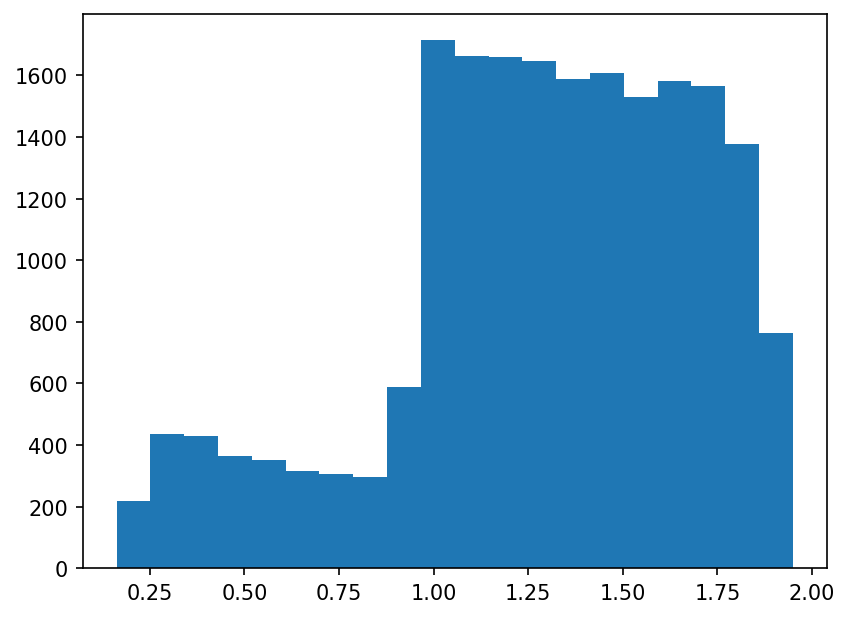

In [73]:
plt.hist(p_values, bins=20)
plt.show()

In [79]:
q = 0.1

k = 1
S = (p_values <= q*k/ds_train.shape[0]).sum()
while S/k >= 1:
    k += 1
    S = (p_values <= q*k/ds_train.shape[0]).sum()
k_star = k-1

In [80]:
k_star

0